# Realistic non-ITF global ocean: ERA5 + OSNAP

This is the realistic global example for the package. The topology is strictly
**without Indonesian Throughflow**.

**Geometry.** The six GEBCO 1000 m traces define five regions. The theory stops
at $55^\circ$S. The Atlantic northern closure is $55^\circ$N; the Pacific
closure is placed at $59^\circ$N where its isobaths support it, while the
Indian closure is limited by its available trace near $24.5^\circ$N.

**Forcing.** OSNAP is the only prescribed northern transport. ERA5 wind-stress
anomalies are converted *upstream* into $\mathbf{M}_{\mathrm{Ek}}$ using an
explicit $\rho_0$, equatorial regularization, and 2-degree coastal taper. The model
does not receive wind stress or a separately prescribed northern Ekman
transport. The southern transport and every internal Ekman section are derived
from the same $\mathbf{M}_{\mathrm{Ek}}$.

Here $h_b$ is evaluated at $x_b$, outside the western boundary-current region
rather than at the coastline; $h_w$ is the western-boundary thickness, not a
westward-propagating thickness.

In [1]:
from pathlib import Path
import os
import sys
import warnings

from amocatlas import read
import cmocean
import dask
from dask.array.core import PerformanceWarning
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "notebooks"))
DATA_ROOT = Path(os.environ["MOC_EXAMPLE_DATA_ROOT"])

from moc_adjustment_theory import GlobalAdjustmentModel, GlobalForcing
from _example_helpers import (
    ekman_transport_from_stress,
    non_itf_geometry,
    plot_geometry,
    regularization_gamma,
    section_transport,
)

plt.rcParams.update({"figure.dpi": 115, "axes.grid": False})
warnings.filterwarnings("ignore", category=PerformanceWarning)

## Observed northern forcing and configured geometry

Loading 1 OSNAP dataset(s):
  0. OSNAP_MOC_MHT_MFT_TimeSeries_201408_202207_2025.nc: Time series of MOC, MHT, and MFT (2014-2022)



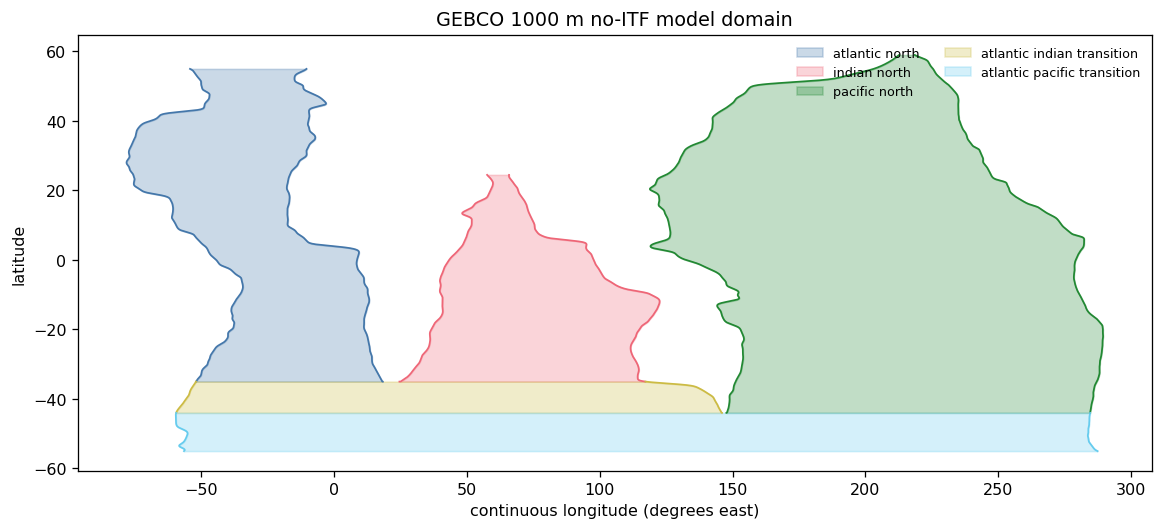

OSNAP record: 2014-08-01 to 2022-07-01 (96 months)
gateways: y_P=-43.99, y_I=-34.99; closures: -55 to 55


In [2]:
osnap = read.osnap(source=DATA_ROOT / "OSNAP", version="2025")
northern = osnap.MOC_SIGMA0.rename({"TIME": "time"})
northern = northern.assign_coords(
    time=np.asarray(northern.time).astype("datetime64[M]")
)

isobaths = xr.open_dataset(
    REPO / "data/tracked/isobath/global_isobath_GEBCO_1000m.nc"
).dropna("latitude", how="all")

def common_support(*names):
    traces = [isobaths[name].dropna("latitude") for name in names]
    return (
        max(float(trace.latitude[0]) for trace in traces),
        min(float(trace.latitude[-1]) for trace in traces),
    )

y_I, _ = common_support("x_wI", "x_eI")
y_P, _ = common_support("x_wP", "x_eP")
y_S, y_N = -55.0, 55.0
y_NI, y_NP = 24.5, 59.0
geometry = non_itf_geometry(
    isobaths,
    y_S=y_S,
    y_P=y_P,
    y_I=y_I,
    y_N=y_N,
    y_NI=y_NI,
    y_NP=y_NP,
)

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
plot_geometry(geometry, ax=ax)
ax.set_title("GEBCO 1000 m no-ITF model domain")
plt.show()

print(
    f"OSNAP record: {str(northern.time.values[0])[:10]} to "
    f"{str(northern.time.values[-1])[:10]} ({northern.sizes['time']} months)"
)
print(f"gateways: y_P={y_P:.2f}, y_I={y_I:.2f}; closures: {y_S:g} to {y_N:g}")

## Upstream ERA5 stress conversion

In [3]:
winds = xr.open_dataset(
    DATA_ROOT / "ERA5/global_winds.nc",
    chunks={},
)[["avg_iews", "avg_inss"]]
winds = winds.assign_coords(
    valid_time=winds.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")
winds = winds.sel(latitude=slice(y_NP, y_S)).sortby("latitude")
winds = winds.sel(time=northern.time).chunk(
    {"time": -1, "latitude": 24, "longitude": 96}
)
stress_anomaly = winds - winds.mean("time")

rho_0 = 1027.0  # upstream choice, not a model parameter
g_prime = 0.02
gamma = regularization_gamma(g_prime, geometry.H)
M_ek = ekman_transport_from_stress(
    stress_anomaly,
    geometry,
    rho_0=rho_0,
    gamma=gamma,
    width_degrees=2.0,
)
southern = section_transport(
    M_ek.M_ek_y,
    geometry,
    region="atlantic_pacific_transition",
    latitude=y_S,
)

forcing = GlobalForcing.from_time_series(
    M_ek_x=M_ek.M_ek_x,
    M_ek_y=M_ek.M_ek_y,
    northern_transport=northern,
    southern_transport=southern,
    sample_interval_seconds=365.25 * 86_400 / 12,
    padding_samples=northern.sizes["time"] - 1,
    n_fft=512,
)
with dask.config.set(scheduler="threads", num_workers=2):
    output = GlobalAdjustmentModel(geometry, forcing, g_prime=g_prime).solve()

## Basin-resolved response

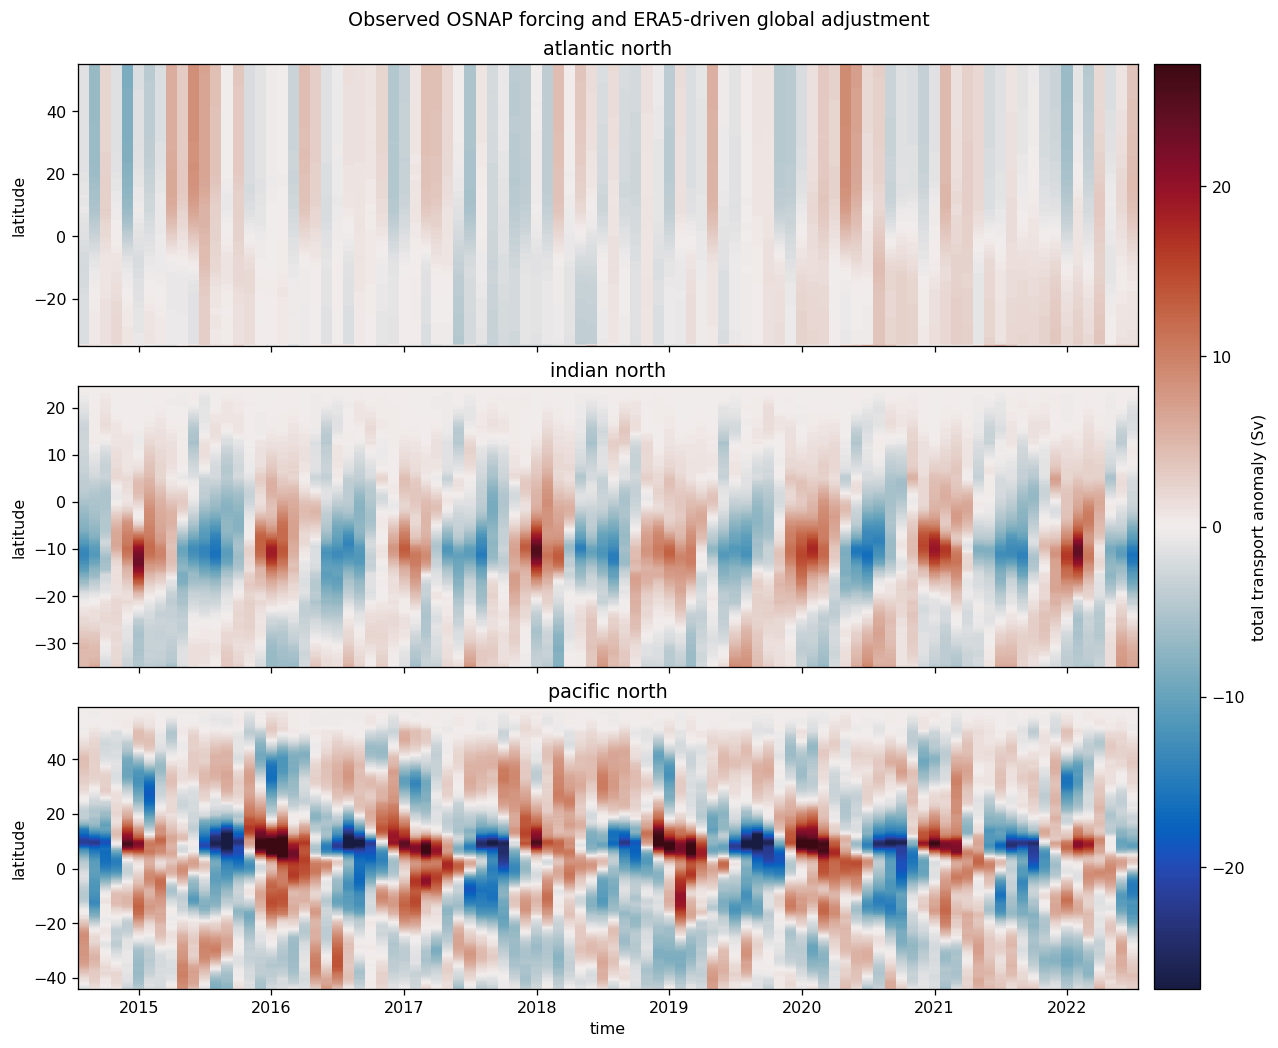

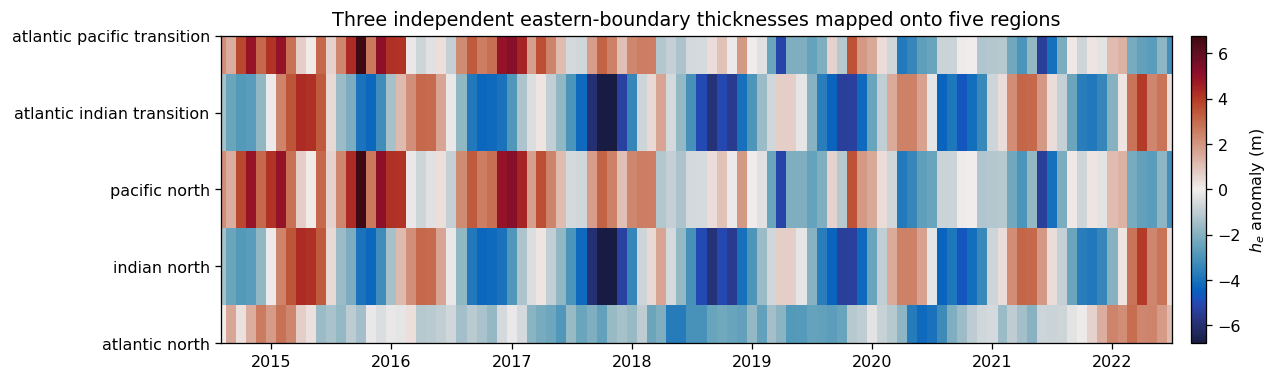

In [4]:
regions = ["atlantic_north", "indian_north", "pacific_north"]
fields = [
    output.transport.sel(region=region).dropna("latitude", how="all") / 1e6
    for region in regions
]
vmax = max(float(abs(field).quantile(0.995)) for field in fields)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
for ax, region, field in zip(axes, regions, fields):
    mesh = field.plot.pcolormesh(
        ax=ax,
        x="time",
        y="latitude",
        cmap=cmocean.cm.balance,
        norm=norm,
        add_colorbar=False,
        rasterized=True,
    )
    ax.set(ylabel="latitude", xlabel="", title=region.replace("_", " "))
fig.colorbar(mesh, ax=axes, pad=0.015, label="total transport anomaly (Sv)")
axes[-1].set_xlabel("time")
fig.suptitle("Observed OSNAP forcing and ERA5-driven global adjustment")
plt.show()

he = output.h_e.assign_coords(
    region=[str(region).replace("_", " ") for region in output.h_e.region.values]
)
fig, ax = plt.subplots(figsize=(11, 3.2), constrained_layout=True)
vmax_h = float(abs(he).quantile(0.995))
mesh = he.transpose("region", "time").plot.pcolormesh(
    ax=ax,
    x="time",
    y="region",
    cmap=cmocean.cm.balance,
    norm=mcolors.TwoSlopeNorm(vmin=-vmax_h, vcenter=0.0, vmax=vmax_h),
    add_colorbar=False,
)
fig.colorbar(mesh, ax=ax, pad=0.02, label=r"$h_e$ anomaly (m)")
ax.set(
    title="Three independent eastern-boundary thicknesses mapped onto five regions",
    xlabel="",
    ylabel="",
)
plt.show()

## Cheap wind-compatibility diagnostic

The three independent eastern-boundary values obey
$h_e^{(1)}=h_A$, $h_e^{(2)}=h_e^{(4)}=h_I$, and
$h_e^{(3)}=h_e^{(5)}=h_P$; the five plotted rows expose that sharing map.

The compatibility residual is a discrete divergence-theorem diagnostic, not
another forcing constraint. On the finite ERA5 grid it contains both
differentiation/integration error and any lateral flux left by the chosen
coastal taper. The final column scales its RMS by the larger RMS of the
regional pumping integral and north-minus-south Ekman section imbalance.

In [5]:
compatibility = output.dataset.compatibility_residual / 1e6
section_imbalance = []
for region in output.transport_ekman.region.values:
    profile = output.transport_ekman.sel(region=region).dropna(
        "latitude", how="all"
    ) / 1e6
    section_imbalance.append(profile.isel(latitude=-1) - profile.isel(latitude=0))
section_imbalance = xr.concat(
    section_imbalance,
    dim=xr.IndexVariable("region", output.transport_ekman.region.values),
)
pumping_integral = compatibility + section_imbalance
rms_residual = np.sqrt((compatibility**2).mean("time"))
rms_reference = xr.apply_ufunc(
    np.maximum,
    np.sqrt((pumping_integral**2).mean("time")),
    np.sqrt((section_imbalance**2).mean("time")),
)
summary = xr.Dataset(
    {
        "rms_Sv": rms_residual,
        "max_abs_Sv": abs(compatibility).max("time"),
        "rms_fraction": rms_residual / rms_reference,
    }
)
print(summary.to_dataframe().round(3).to_string())

                             rms_Sv  max_abs_Sv  rms_fraction
region                                                       
atlantic_north                0.031       0.096         0.012
indian_north                  0.934       1.692         0.185
pacific_north                 0.568       1.676         0.189
atlantic_indian_transition    1.334       4.007         0.371
atlantic_pacific_transition   0.087       0.231         0.009
